# Do the log-normal $\mu$ and $\sigma$ correlate with environment?

For each calibration site we fitted a log-normal soil-age distribution with parameters $\mu$ (log-scale location) and $\sigma$ (log-scale spread). Here we ask whether those parameters track environmental conditions:

* **Climate** — WorldClim v1 bioclimatic variables `bio01`-`bio19`.
* **Soil (edaphic)** — SoilGrids 0-30 cm bulk density, pH, clay %, and CEC.

Covariates were sampled at the site coordinates with Earth Engine in [fetch_site_env_data.py](fetch_site_env_data.py) and cached to `results/03_calibrate_models/site_env_covariates.csv`, so this notebook does not need Earth Engine access.

**Multiple testing:** we scan 23 covariates per parameter, so raw $p$-values overstate significance. We control the false-discovery rate with the Benjamini-Hochberg procedure *within each target column* (family = the 23 covariates tested for that one parameter) and report adjusted $q$-values; significance markers use $q<0.05$.

*Caveat:* in steady state $\mu$ and $\sigma$ are tied to turnover time $T$ and the age-amplification $A$ ($\sigma^2=\ln A-\ln T$, $\mu=\sigma^2/2-\ln T$). Any climate signal in $\mu,\sigma$ largely reflects climate control on $T$ and $A$, so we report those alongside.

In [1]:
import os
if os.getcwd().endswith('experimental'):
    os.chdir('../..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from statsmodels.stats.multitest import multipletests
plt.style.use('notebooks/style.mpl')

### Load fits + covariates and merge per site

In [2]:
ln = pd.read_csv('results/03_calibrate_models/03b_lognormal_predictions_calcurve.csv')
# log-normal params from the steady-state relations (see plot_lognormal_param_corr.ipynb)
ln['sigma'] = np.sqrt(np.log(ln['pred'] / ln['turnover']))
ln['mu'] = -np.log(np.sqrt(ln['turnover']**3 / ln['pred']))
ln = ln.rename(columns={'pred': 'A'}).drop_duplicates(subset=['Longitude', 'Latitude'])

env = pd.read_csv('results/03_calibrate_models/site_env_covariates.csv')
df = ln.merge(env, on=['Latitude', 'Longitude'], how='left')

env_cols = [c for c in env.columns if c not in ('Latitude', 'Longitude')]
targets = ['mu', 'sigma', 'turnover', 'A']
# friendly names for the bioclim variables
bio_names = {
    'bio01': 'Annual mean T', 'bio02': 'Mean diurnal T range', 'bio03': 'Isothermality',
    'bio04': 'T seasonality', 'bio05': 'Max T warmest mo', 'bio06': 'Min T coldest mo',
    'bio07': 'Annual T range', 'bio08': 'T wettest qtr', 'bio09': 'T driest qtr',
    'bio10': 'T warmest qtr', 'bio11': 'T coldest qtr', 'bio12': 'Annual precip',
    'bio13': 'Precip wettest mo', 'bio14': 'Precip driest mo', 'bio15': 'Precip seasonality',
    'bio16': 'Precip wettest qtr', 'bio17': 'Precip driest qtr', 'bio18': 'Precip warmest qtr',
    'bio19': 'Precip coldest qtr', 'bdod_0-30cm': 'Bulk density', 'phh2o_0-30cm': 'pH',
    'clay_0-30cm': 'Clay %', 'cec_0-30cm': 'CEC'}
print(f'{len(df)} sites; {len(env_cols)} covariates')
df[['Latitude', 'Longitude', 'mu', 'sigma', 'turnover', 'A'] + env_cols].head()

74 sites; 23 covariates


,Latitude,Longitude,mu,sigma,turnover,A,bio01,bio02,bio03,bio04,...,bio14,bio15,bio16,bio17,bio18,bio19,bdod_0-30cm,phh2o_0-30cm,clay_0-30cm,cec_0-30cm
0,-28.666667,153.333333,0.702852,2.572156,13.533127,10108.432910,18.8,10.4,51.0,355.3,...,50.0,41.0,660.0,204.0,589.0,273.0,1.170000,5.200000,25.333333,22.983333
1,-27.983333,148.550000,0.856360,2.716747,17.013320,27301.854197,20.5,13.9,47.0,563.1,...,25.0,35.0,202.0,90.0,198.0,92.0,1.366667,7.733333,33.883333,20.983333
2,-26.583333,151.833333,0.148514,2.553643,22.466674,15262.085428,18.1,13.8,51.0,451.1,...,33.0,40.0,318.0,116.0,318.0,121.0,1.371667,6.550000,36.416667,25.166667
3,-23.216667,143.950000,-0.591838,2.467259,37.921649,16695.433415,23.5,15.3,50.0,534.7,...,7.0,67.0,213.0,34.0,208.0,45.0,1.441667,8.000000,45.416667,32.833333
4,-22.720000,-47.630000,1.106312,2.644402,10.914794,11884.391988,20.7,11.7,62.0,244.0,...,25.0,67.0,627.0,92.0,566.0,92.0,NaN,NaN,NaN,NaN


### Correlation matrix with FDR control
Spearman rank correlation of each covariate with $\mu$, $\sigma$, $T$ and $A$. We compute raw $p$-values and then Benjamini-Hochberg $q$-values within each target column. Stars in the heatmap mark $q<0.05$.

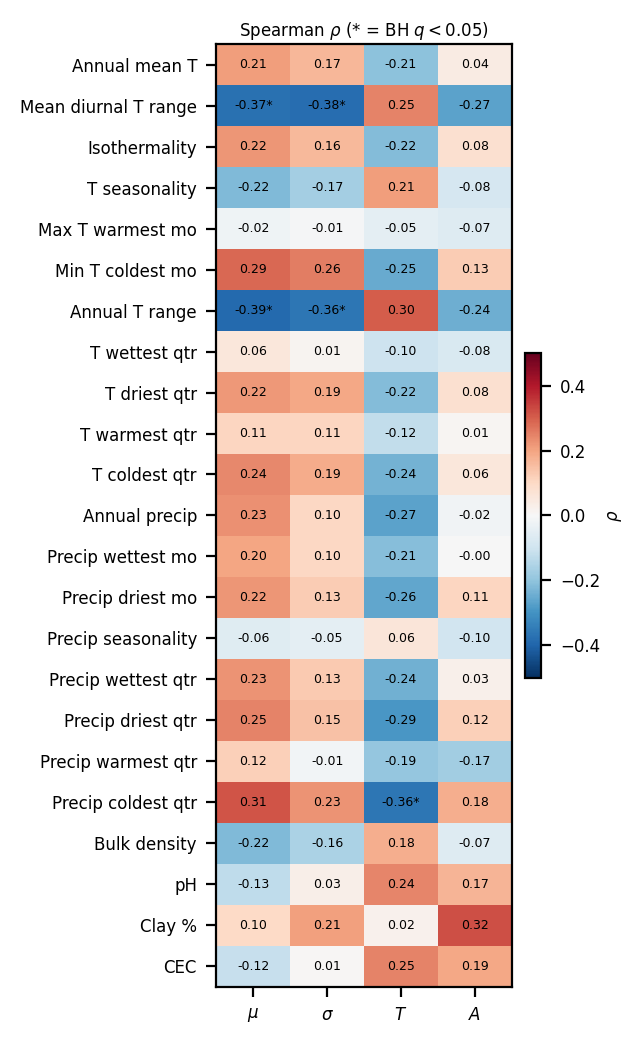

In [3]:
def corr_table(method='spearman'):
    fun = spearmanr if method == 'spearman' else pearsonr
    rho = pd.DataFrame(index=env_cols, columns=targets, dtype=float)
    pval = rho.copy()
    for ec in env_cols:
        for t in targets:
            sub = df[[ec, t]].dropna()
            if len(sub) < 10:
                continue
            r, p = fun(sub[ec], sub[t])
            rho.loc[ec, t], pval.loc[ec, t] = r, p
    # Benjamini-Hochberg FDR within each target column
    qval = pval.copy()
    for t in targets:
        col = pval[t].astype(float)
        mask = col.notna()
        if mask.sum() > 0:
            qval.loc[mask, t] = multipletests(col[mask], method='fdr_bh')[1]
    return rho, pval.astype(float), qval.astype(float)

rho, pval, qval = corr_table('spearman')
labels = [bio_names.get(i, i) for i in env_cols]
for d in (rho, pval, qval):
    d.index = labels

fig, ax = plt.subplots(figsize=(3.2, 5.2), dpi=200)
im = ax.imshow(rho.values.astype(float), cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
ax.set_xticks(range(len(targets)))
ax.set_xticklabels(['$\\mu$', '$\\sigma$', '$T$', '$A$'])
ax.set_yticks(range(len(rho.index)))
ax.set_yticklabels(rho.index)
for i in range(rho.shape[0]):
    for j in range(rho.shape[1]):
        r, q = rho.values[i, j], qval.values[i, j]
        if np.isfinite(r):
            star = '*' if (np.isfinite(q) and q < 0.05) else ''
            ax.text(j, i, f'{r:.2f}{star}', ha='center', va='center',
                    fontsize=4.5, color='k')
ax.set_title('Spearman $\\rho$ (* = BH $q<0.05$)')
cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
cbar.set_label('$\\rho$')
fig.tight_layout()
fig.savefig('figures/lognormal_param_env_corr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Raw $p$ vs FDR $q$ for $\mu$ and $\sigma$
How many associations survive multiple-testing correction.

In [4]:
summary = []
for t in ['mu', 'sigma']:
    tab = pd.DataFrame({'rho': rho[t], 'p_raw': pval[t], 'q_BH': qval[t]})
    tab = tab.reindex(tab['rho'].abs().sort_values(ascending=False).index)
    tab.insert(0, 'target', t)
    summary.append(tab.head(6))
out = pd.concat(summary).round(4)
n_sig_p = {t: int((pval[t] < 0.05).sum()) for t in ['mu', 'sigma']}
n_sig_q = {t: int((qval[t] < 0.05).sum()) for t in ['mu', 'sigma']}
print('# covariates with raw p<0.05 :', n_sig_p)
print('# covariates with BH  q<0.05 :', n_sig_q)
out

# covariates with raw p<0.05 : {'mu': 6, 'sigma': 3}
# covariates with BH  q<0.05 : {'mu': 2, 'sigma': 2}


,target,rho,p_raw,q_BH
Annual T range,mu,-0.3869,0.0007,0.0125
Mean diurnal T range,mu,-0.3749,0.0011,0.0125
Precip coldest qtr,mu,0.3143,0.0068,0.0519
Min T coldest mo,mu,0.2876,0.0136,0.0783
Precip driest qtr,mu,0.2468,0.0353,0.1256
T coldest qtr,mu,0.2400,0.0409,0.1256
Mean diurnal T range,sigma,-0.3792,0.0009,0.0192
Annual T range,sigma,-0.3616,0.0017,0.0192
Min T coldest mo,sigma,0.2554,0.0292,0.2240
Precip coldest qtr,sigma,0.2263,0.0542,0.3114


### Strongest correlates of $\mu$ and $\sigma$
Bars filled if they pass BH $q<0.05$, hollow otherwise.

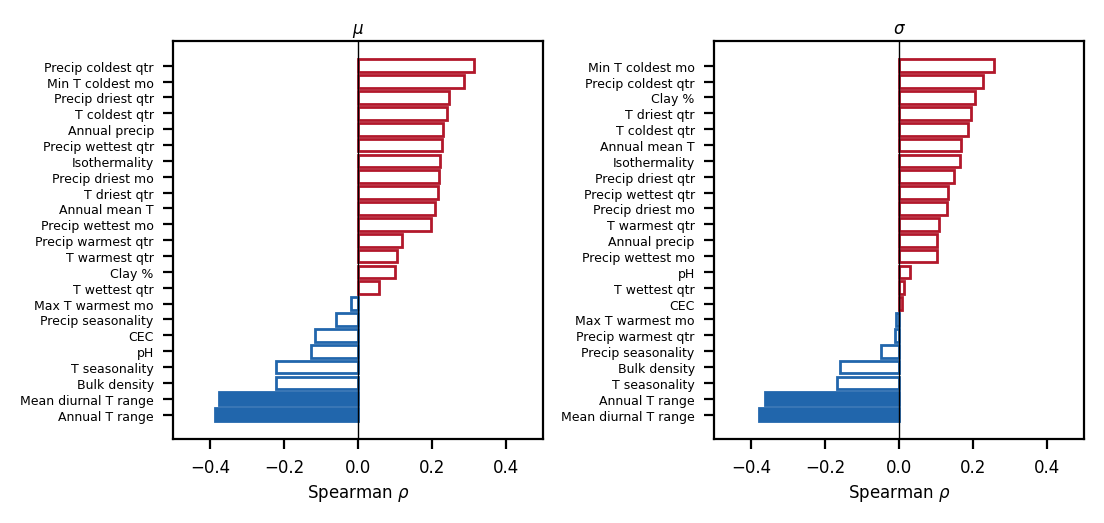

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.6), dpi=200)
for ax, t in zip(axes, ['mu', 'sigma']):
    s = rho[t].astype(float).dropna().sort_values()
    q = qval[t].reindex(s.index)
    for k, (name, v) in enumerate(s.items()):
        base = '#b2182b' if v > 0 else '#2166ac'
        sig = np.isfinite(q[name]) and q[name] < 0.05
        ax.barh(k, v, color=base if sig else 'none',
                edgecolor=base, hatch=None if sig else '')
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels(s.index, fontsize=4.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('Spearman $\\rho$')
    ax.set_title('$\\mu$' if t == 'mu' else '$\\sigma$')
    ax.set_xlim(-0.5, 0.5)
fig.tight_layout()
fig.savefig('figures/lognormal_param_env_corr_bars.png', dpi=300, bbox_inches='tight')
plt.show()

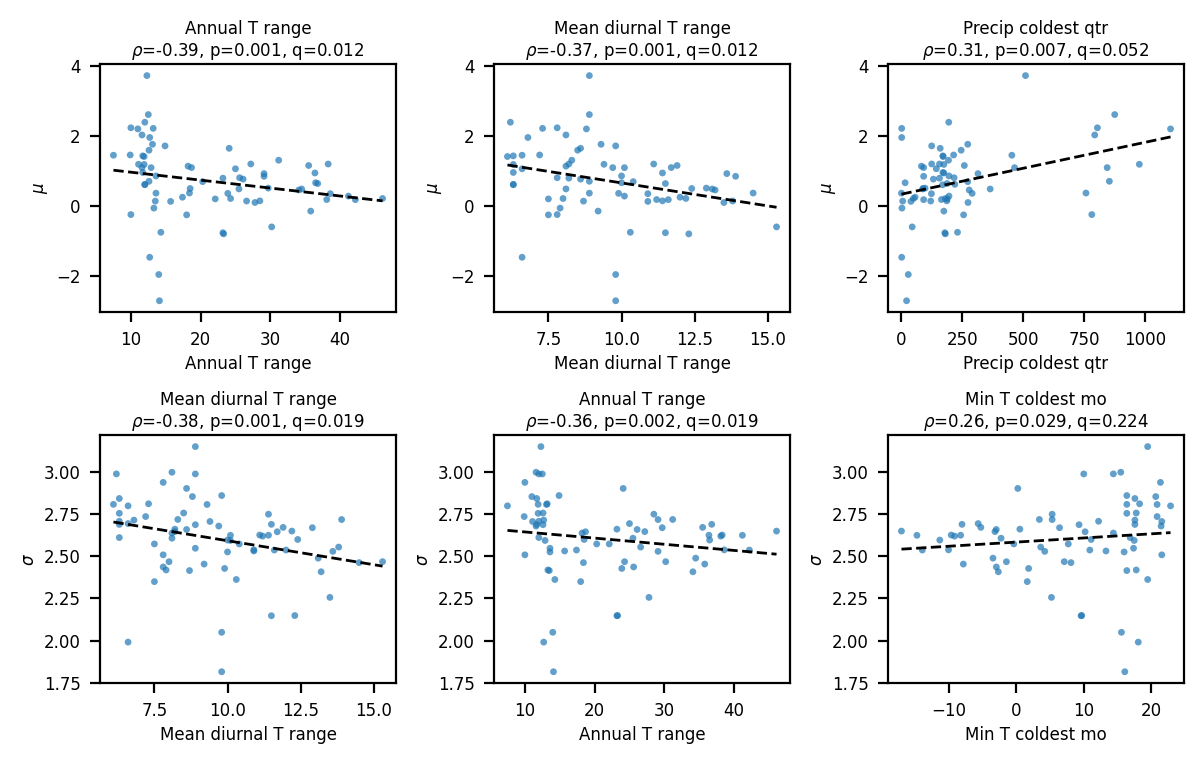

In [6]:
# scatter the 3 strongest covariates for each of mu and sigma, with raw p and BH q
fig, axes = plt.subplots(2, 3, figsize=(6, 3.8), dpi=200)
inv = {bio_names.get(k, k): k for k in env_cols}
for r_i, t in enumerate(['mu', 'sigma']):
    top = rho[t].astype(float).abs().dropna().sort_values(ascending=False).index[:3]
    for c_i, name in enumerate(top):
        ec = inv[name]
        ax = axes[r_i, c_i]
        sub = df[[ec, t]].dropna()
        ax.scatter(sub[ec], sub[t], s=6, alpha=0.7, edgecolor='none')
        b, a = np.polyfit(sub[ec], sub[t], 1)
        xs = np.array([sub[ec].min(), sub[ec].max()])
        ax.plot(xs, a + b * xs, 'k--', lw=1)
        rr = rho.loc[name, t]; pp = pval.loc[name, t]; qq = qval.loc[name, t]
        ax.set_title(f'{name}\n$\\rho$={rr:.2f}, p={pp:.3f}, q={qq:.3f}')
        ax.set_xlabel(name)
        ax.set_ylabel('$\\mu$' if t == 'mu' else '$\\sigma$')
fig.tight_layout()
fig.savefig('figures/lognormal_param_env_corr_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

### How much variance can environment explain jointly?
Multiple linear regression of each parameter on the standardized covariates (climate-only, soil-only, and combined). $R^2$ is in-sample, so it is an optimistic upper bound given 74 sites and ~23 predictors; treat it as a rough ceiling on explanatory power rather than a predictive estimate.

In [7]:
from numpy.linalg import lstsq
clim_cols = [c for c in env_cols if c.startswith('bio')]
soil_cols = [c for c in env_cols if not c.startswith('bio')]

def r2(target, cols):
    sub = df[[target] + cols].dropna()
    X = sub[cols].to_numpy(float)
    X = (X - X.mean(0)) / X.std(0)
    X = np.column_stack([np.ones(len(X)), X])
    y = sub[target].to_numpy(float)
    beta, *_ = lstsq(X, y, rcond=None)
    yhat = X @ beta
    ss_res = ((y - yhat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    n, p = len(y), X.shape[1] - 1
    r2 = 1 - ss_res / ss_tot
    adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return r2, adj, n

out = []
for t in ['mu', 'sigma', 'turnover', 'A']:
    for label, cols in [('climate', clim_cols), ('soil', soil_cols),
                        ('climate+soil', clim_cols + soil_cols)]:
        r2v, adj, n = r2(t, cols)
        out.append((t, label, len(cols), n, round(r2v, 2), round(adj, 2)))
pd.DataFrame(out, columns=['target', 'predictors', 'k', 'n', 'R2', 'adj_R2'])

/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_31653/2796480330.py:12: RuntimeWarning: divide by zero encountered in matmul
  yhat = X @ beta
/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_31653/2796480330.py:12: RuntimeWarning: overflow encountered in matmul
  yhat = X @ beta
/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_31653/2796480330.py:12: RuntimeWarning: invalid value encountered in matmul
  yhat = X @ beta
/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_31653/2796480330.py:12: RuntimeWarning: divide by zero encountered in matmul
  yhat = X @ beta
/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_31653/2796480330.py:12: RuntimeWarning: overflow encountered in matmul
  yhat = X @ beta
/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_31653/2796480330.py:12: RuntimeWarning: invalid value encountered in matmul
  yhat = X @ beta
/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_31653/2796480330.py:12: Runtime

,target,predictors,k,n,R2,adj_R2
0,mu,climate,19,73,0.39,0.17
1,mu,soil,4,67,0.08,0.02
2,mu,climate+soil,23,67,0.53,0.28
3,sigma,climate,19,73,0.40,0.18
4,sigma,soil,4,67,0.11,0.06
5,sigma,climate+soil,23,67,0.61,0.40
6,turnover,climate,19,73,0.39,0.16
7,turnover,soil,4,67,0.05,-0.01
8,turnover,climate+soil,23,67,0.48,0.21
9,A,climate,19,73,0.40,0.18


### Takeaways
* After Benjamini-Hochberg FDR correction (within each parameter's family of 23 covariates), the temperature-range variables remain the standout signal for both $\mu$ and $\sigma$ (`bio02` mean diurnal range, `bio07` annual range; both negative). The weaker raw-significant hits (e.g. `bio17`, `bio11`) do **not** survive correction.
* Edaphic factors (bulk density, pH, clay, CEC) are weak and none survive FDR.
* The adjusted $R^2$ table shows whether climate adds genuine joint explanatory power once the predictor count is penalized.